In [12]:
!pip install -q rfdetr==1.2.1 supervision==0.26.1 roboflow
print("done")

done


In [69]:
import torch
device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
print(f"Device: {device}")

Device: mps


In [4]:
import torch
print("PyTorch version:", torch.__version__)
print("MPS available:", torch.backends.mps.is_available())
print("Current device:", torch.cuda.current_device() if torch.cuda.is_available() else "No CUDA")

import os
print("MPS Fallback env var:", os.environ.get('PYTORCH_ENABLE_MPS_FALLBACK', 'Not set'))

# Check RF-DETR version if possible
import rfdetr
print("RF-DETR version:", getattr(rfdetr, '__version__', 'Unknown'))

PyTorch version: 2.7.1
MPS available: True
Current device: No CUDA
MPS Fallback env var: 1
RF-DETR version: Unknown


In [6]:
from rfdetr import RFDETRNano

model = RFDETRNano(pretrain_weights="/Volumes/external/Research_ssd/checkpoint_best_ema.pth", device = "mps")
model.optimize_for_inference()
print("loaded fine tuned model")

Using a different number of positional encodings than DINOv2, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.
Using patch size 16 instead of 14, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.
Loading pretrain weights


num_classes mismatch: pretrain weights has 1 classes, but your model has 90 classes
reinitializing detection head with 1 classes


loaded fine tuned model


In [87]:
import supervision as sv

ds = sv.DetectionDataset.from_coco(
    images_directory_path=f"",
    annotations_path=f"",
)
# path to the images and path to the coco json file that has the ground truth bounding box annotation coordinates. the coco dataset was generated from my own custom roboflow workspace, contact me if you want access to it

running inference on one image


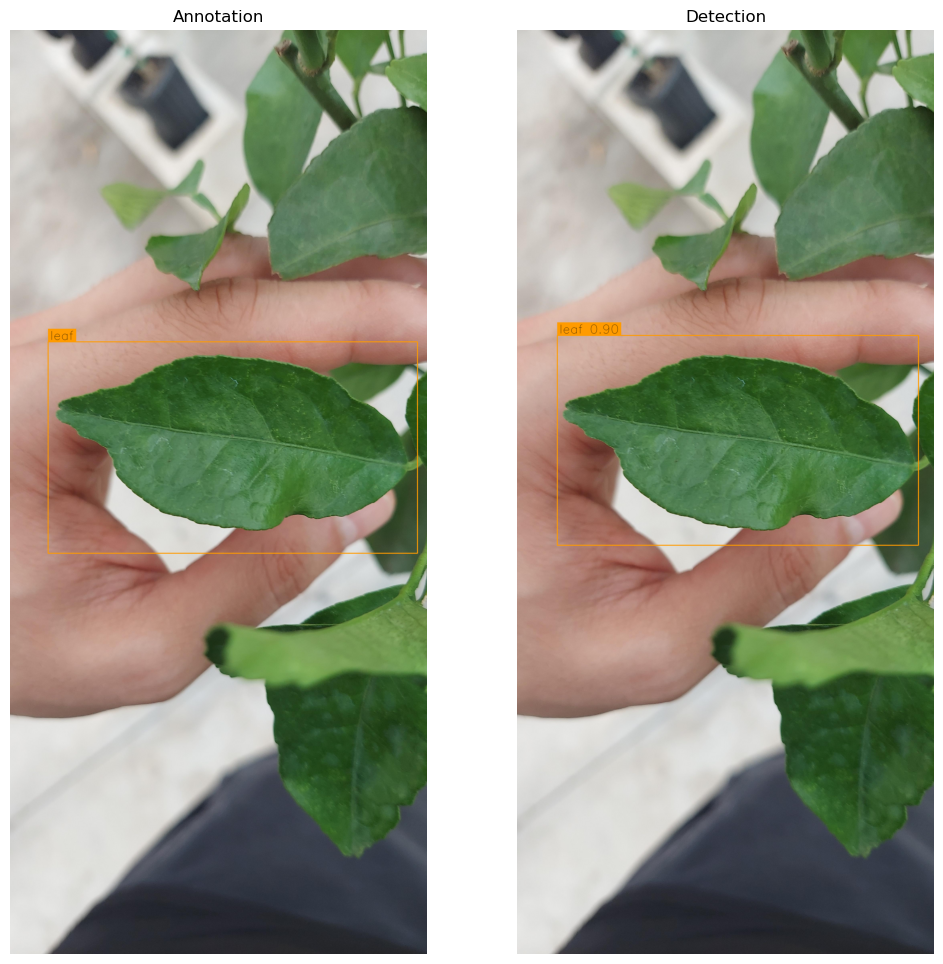

In [93]:
from rfdetr import RFDETRBase
import supervision as sv
from PIL import Image

print("running inference on one image")

path, image, annotations = ds[0]
image = Image.open(path)

detections = model.predict(image, threshold=0.5)

text_scale = sv.calculate_optimal_text_scale(resolution_wh=image.size)
thickness = sv.calculate_optimal_line_thickness(resolution_wh=image.size)
color = sv.ColorPalette.from_hex([
    "#ffff00", "#ff9b00", "#ff66ff", "#3399ff", "#ff66b2", "#ff8080",
    "#b266ff", "#9999ff", "#66ffff", "#33ff99", "#66ff66", "#99ff00"
])

bbox_annotator = sv.BoxAnnotator(color=color,thickness=thickness)
label_annotator = sv.LabelAnnotator(
    color=color,
    text_color=sv.Color.BLACK,
    text_scale=text_scale)

annotations_labels = [
    f"{ds.classes[class_id]}"
    for class_id
    in annotations.class_id
]

detections_labels = [
    f"{ds.classes[class_id]} {confidence:.2f}"
    for class_id, confidence
    in zip(detections.class_id, detections.confidence)
]

annotation_image = image.copy()
annotation_image = bbox_annotator.annotate(annotation_image, annotations)
annotation_image = label_annotator.annotate(annotation_image, annotations, annotations_labels)

detections_image = image.copy()
detections_image = bbox_annotator.annotate(detections_image, detections)
detections_image = label_annotator.annotate(detections_image, detections, detections_labels)

sv.plot_images_grid(images=[annotation_image, detections_image], grid_size=(1, 2), titles=["Annotation", "Detection"])

RUNNING INFERENCE ON 9 IMAGES


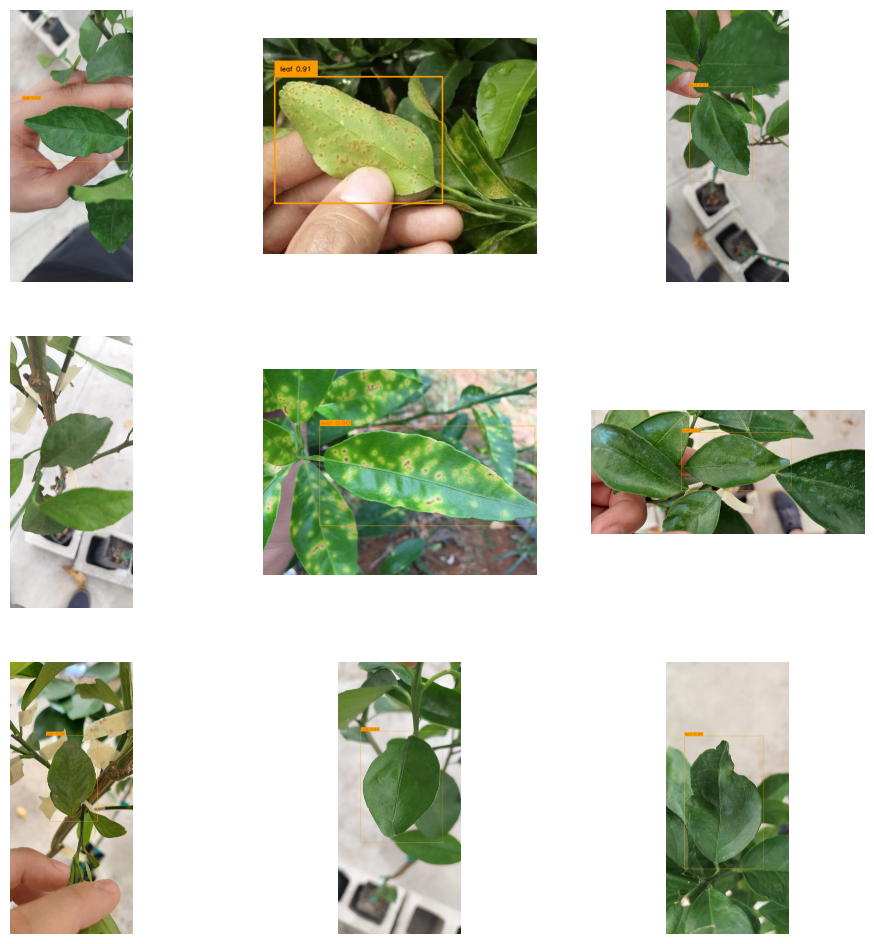

In [91]:
import supervision as sv
from PIL import Image

detections_images = []

print("RUNNING INFERENCE ON 9 IMAGES")

for i in range(9):
    path, image, annotations = ds[i]
    image = Image.open(path)

    detections = model.predict(image, threshold=0.5)

    text_scale = sv.calculate_optimal_text_scale(resolution_wh=image.size)
    thickness = sv.calculate_optimal_line_thickness(resolution_wh=image.size)
    color = sv.ColorPalette.from_hex([
        "#ffff00", "#ff9b00", "#ff66ff", "#3399ff", "#ff66b2", "#ff8080",
        "#b266ff", "#9999ff", "#66ffff", "#33ff99", "#66ff66", "#99ff00"
    ])

    bbox_annotator = sv.BoxAnnotator(color=color, thickness=thickness)
    label_annotator = sv.LabelAnnotator(
        color=color,
        text_color=sv.Color.BLACK,
        text_scale=text_scale)

    detections_labels = [
        f"{ds.classes[class_id]} {confidence:.2f}"
        for class_id, confidence
        in zip(detections.class_id, detections.confidence)
    ]

    detections_image = image.copy()
    detections_image = bbox_annotator.annotate(detections_image, detections)
    detections_image = label_annotator.annotate(detections_image, detections, detections_labels)

    detections_images.append(detections_image)

sv.plot_images_grid(images=detections_images, grid_size=(3, 3), size=(12, 12))